<a href="https://colab.research.google.com/github/miaflynn/CYPLAN255-Final-Project/blob/main/cleaning1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install contextily

In [2]:
import pandas as pd
import geopandas as gpd
import numpy as np

#added more that we use in lab
import os
%matplotlib inline
import matplotlib.pyplot as plt
from shapely.geometry import LineString


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
!ls /content/drive
!ls /content/drive/Shareddrives

MyDrive  Shareddrives


In [5]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/C255_final_project/raw/rbl_sf.csv")

In [6]:
gdf = df
gdf.head()

,UniqueID,Business Account Number,Location Id,Ownership Name,DBA Name,Street Address,City,State,Source Zipcode,Business Start Date,...,LIC Code Descriptions List,Parking Tax,Transient Occupancy Tax,Business Location,Business Corridor,Neighborhoods - Analysis Boundaries,Supervisor District,Community Benefit District,data_as_of,data_loaded_at
0,1409882-02-261-1178986,1178986,1409882-02-261,Norried's Inc,Norried's Painting,110 Sequoia Way,Martinez,CA,94553.0,11/10/2025,...,NaN,False,False,POINT (-122.124125083 37.974967672),NaN,NaN,NaN,NaN,2026/03/05 12:00:00 AM,2026/03/05 04:21:06 AM
1,1129903-12-161-1062349,1062349,1129903-12-161,Rostker Fanya,Dentrans,73 Westpark Dr,Daly City,CA,94015.0,12/12/2016,...,NaN,False,False,POINT (-122.484967021 37.706274995),NaN,NaN,NaN,NaN,2026/03/05 12:00:00 AM,2026/03/05 04:21:06 AM
2,1031796-06-151-1015153,1015153,1031796-06-151,American Glazing & Aluminum,Parkmerced,815 Arnold Dr Ste 11,Martinez,CA,94553.0,06/22/2015,...,NaN,False,False,POINT (-122.115083021 37.998423003),NaN,NaN,NaN,NaN,2026/03/05 12:00:00 AM,2026/03/05 04:21:06 AM
3,1006390-09-141-1003467,1003467,1006390-09-141,King Jim,Woodland Construction,4524 Salida Blvd,Salida,CA,95368.0,09/03/2014,...,NaN,False,False,POINT (-121.078333967 37.704319999),NaN,NaN,NaN,NaN,2026/03/05 12:00:00 AM,2026/03/05 04:21:06 AM
4,0406369-01-999-0406369,406369,0406369-01-999,Billings Michael,Billings Michael,1015 Dante Ave,Oakland,CA,94603.0,01/01/2007,...,NaN,False,False,NaN,NaN,NaN,NaN,NaN,2026/03/05 12:00:00 AM,2026/03/05 04:21:06 AM


In [7]:
###renaming columns

new_names = gdf.columns.str.strip().str.replace(' #', '_num').str.replace(' - ', '_').str.replace(' ', '_').str.lower()
gdf.columns = new_names
gdf.columns

Index(['uniqueid', 'business_account_number', 'location_id', 'ownership_name',
       'dba_name', 'street_address', 'city', 'state', 'source_zipcode',
       'business_start_date', 'business_end_date', 'location_start_date',
       'location_end_date', 'administratively_closed', 'mail_address',
       'mail_city', 'mail_state', 'mail_zipcode', 'naics_code',
       'naics_code_description', 'naics_code_descriptions_list', 'lic_code',
       'lic_code_description', 'lic_code_descriptions_list', 'parking_tax',
       'transient_occupancy_tax', 'business_location', 'business_corridor',
       'neighborhoods_analysis_boundaries', 'supervisor_district',
       'community_benefit_district', 'data_as_of', 'data_loaded_at'],
      dtype='object')

In [8]:
num_duplicates = gdf.duplicated().sum()
pct_duplicates = (num_duplicates / len(gdf)) * 100
print(num_duplicates, pct_duplicates)

##no duplicates in dataset

0 0.0


In [9]:
type(gdf)

pandas.core.frame.DataFrame

In [10]:
##fixing geometries of business location column

#I'm adjusting this code a little bc it's not running for me

from shapely import wkt

# Making copy and removing rows without location data bc it won't run otherwise
df = df[df["business_location"].notna()].copy()

# Converting string to geometry
df["geometry"] = df["business_location"].apply(wkt.loads)

#Right now it's a df so I'm making it a gdf
gdf = gpd.GeoDataFrame(df, geometry="geometry", crs="EPSG:4326")


In [11]:
##setting geomtery
gdf = gdf.set_geometry('geometry')

In [12]:
##setting crs and correcting datetimes

gdf['business_start_date'] = pd.to_datetime(gdf['business_start_date'], format = '%m/%d/%Y', errors = 'coerce')
gdf['business_end_date'] = pd.to_datetime(gdf['business_end_date'], format = '%m/%d/%Y', errors = 'coerce')
gdf['location_start_date'] = pd.to_datetime(gdf['location_start_date'], format = '%m/%d/%Y', errors = 'coerce')
gdf['location_end_date'] = pd.to_datetime(gdf['location_end_date'], format = '%m/%d/%Y', errors = 'coerce')
gdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 344373 entries, 0 to 356174
Data columns (total 34 columns):
 #   Column                             Non-Null Count   Dtype         
---  ------                             --------------   -----         
 0   uniqueid                           344373 non-null  object        
 1   business_account_number            344373 non-null  int64         
 2   location_id                        344373 non-null  object        
 3   ownership_name                     344372 non-null  object        
 4   dba_name                           344051 non-null  object        
 5   street_address                     344373 non-null  object        
 6   city                               344288 non-null  object        
 7   state                              344112 non-null  object        
 8   source_zipcode                     344114 non-null  float64       
 9   business_start_date                344373 non-null  datetime64[ns]
 10  business_end_date

In [13]:
missing = gdf.isna().sum()
display(missing.sort_values(ascending=False))

,0
lic_code_descriptions_list,331288
lic_code_description,331288
lic_code,331228
business_corridor,311833
administratively_closed,303075
community_benefit_district,269852
mail_state,185972
mail_zipcode,185940
mail_city,185922
mail_address,185912


In [14]:
##admin closed to boolean
admin_closed_mask = gdf['administratively_closed'] == '***Administratively Closed'
gdf['administratively_closed_bool'] = admin_closed_mask

13145
166190


,naics_code,naics_code_description,lic_code,lic_code_description
112796,5400-5499,"Professional, Scientific, and Technical Services",NaN,NaN
134756,5400-5499,"Professional, Scientific, and Technical Services",NaN,NaN
312627,5210-5239,Financial Services,NaN,NaN
143527,4200-4299 4400-4599,Multiple,NaN,NaN
34370,4400-4599,Retail Trade,NaN,NaN
62775,5300-5399,Real Estate and Rental and Leasing Services,NaN,NaN
129665,6100-6299,Private Education and Health Services,NaN,NaN
128178,5300-5399,Real Estate and Rental and Leasing Services,NaN,NaN
172604,4400-4599,Retail Trade,NaN,NaN
104565,5300-5399,Real Estate and Rental and Leasing Services,NaN,NaN


<Axes: >

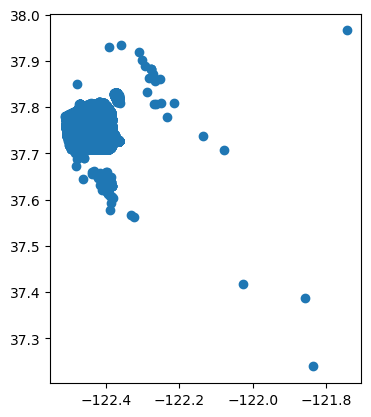

In [15]:
## filtering for having a code

lic_mask = gdf['lic_code'].notna()
print(lic_mask.sum())
naics_mask = gdf['naics_code'].notna()
print(naics_mask.sum())
gdf_hascode = gdf[lic_mask | naics_mask]

code_cols = [
    'naics_code', 'naics_code_description', 'lic_code','lic_code_description'
]

display(gdf_hascode[code_cols].sample(20))

##filtered only by businesses with code, but still having business locations all across the United States?
# I think a lot of the addresses are elsewhere bc the business headquarters location may not be in SF - if you look at the table it shows this - Abigail

# Commenting this out bc I'm going to also filter the boundaries of Sf - Abigail
# gdf_hascode_sf = gdf_hascode[gdf_hascode['city'] == 'San Francisco']

# Bounds from here: https://wiki.openstreetmap.org/wiki/San_Francisco,_California
sanfran_bounds = {
    "minx": -123,
    "maxx": -121.5,
    "miny": 37,
    "maxy": 38
}

gdf_hascode_sf = gdf_hascode[
    (gdf_hascode['city'] == 'San Francisco') &
    (gdf_hascode.geometry.x >= sanfran_bounds["minx"]) &
    (gdf_hascode.geometry.x <= sanfran_bounds["maxx"]) &
    (gdf_hascode.geometry.y >= sanfran_bounds["miny"]) &
    (gdf_hascode.geometry.y <= sanfran_bounds["maxy"])
]

gdf_hascode_sf.plot()

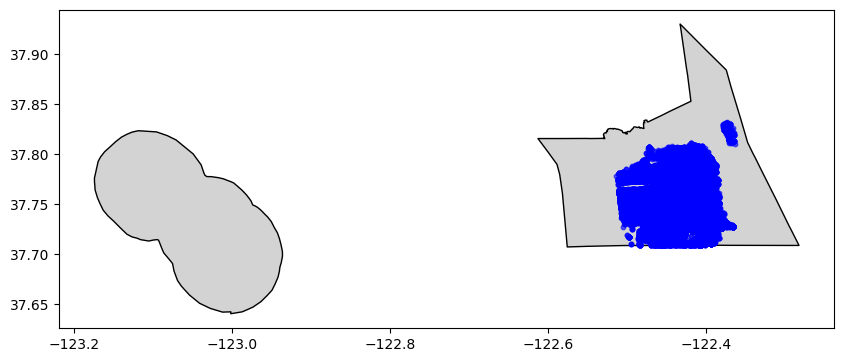

In [16]:
# adding another plot and importing a shpfile of SF so we can see where the points are in SF

import matplotlib.pyplot as plt

# Importing SF geometry
# URL for 2025 TIGER/Line Place boundaries - info here on
## how to use: https://www.census.gov/geographies/mapping-files/time-series/geo/tiger-line-file.html
url = "https://www2.census.gov/geo/tiger/TIGER2025/PLACE/tl_2025_06_place.zip"

places = gpd.read_file(url)

# Filtered to SF
sf_poly = places[
    (places["NAME"] == "San Francisco") &
    (places["STATEFP"] == "06")   # 06 = California
]


# eproject to same as our gdf
sf_poly = sf_poly.to_crs(epsg=4326)

# keeping just the points in sf bc there are a lot outside
gdf_sf = gpd.sjoin(gdf_hascode_sf, sf_poly, predicate="within") ##joined with gdf_hascode_sf instead, so we only have coded businesses -Sean

fig, ax = plt.subplots(figsize=(10,10))

# plotting the boundary of SF
sf_poly.plot(ax=ax, color="lightgray", edgecolor="black")

# plotting business points on top
gdf_sf.plot(ax=ax, color="blue", markersize=10, alpha=0.6)

plt.show()

# the circles to the left are the farallon islands lol don't need that

####Cleaning decisions to make
*   What years do we want to narrow to?
    * 2016-2026
*   What business types do we want to include?
    * Professional, Scientific, and Technical Services; Retail Trade; Private Education and Health Services; Arts, Entertainment, and Recreation; Financial Service; Information; Multiple; Certain Services; Wholesale Trade

*   Do we want to look at business or location start/end dates? I'm thinking location makes the most sense - Abigail
    * Location start and end date
* Which columns can we drop? - Abigail

    * Imp - This is from the metadata: When the City transitioned to a new system in 2014, only active business accounts were migrated. As a result, any businesses that had already closed by that point were not included in the current dataset.In 2018, TTX did a major cleanup of dormant and unresponsive accounts and closed approximately 40,000 inactive businesses. - Abigail
  

* Look @ this: https://opendatasanfrancisco.com/registered-businesses - Abigail




In [17]:
##quickly looking at gdf_sf codes

display(gdf_sf['naics_code_description'].value_counts())
display(gdf_sf['lic_code_description'].value_counts())

,count
naics_code_description,
Real Estate and Rental and Leasing Services,26280
"Professional, Scientific, and Technical Services",23574
Food Services,12813
Retail Trade,12380
Private Education and Health Services,8821
"Arts, Entertainment, and Recreation",8144
Accommodations,7775
Construction,7281
Financial Services,4883


,count
lic_code_description,
Multiple,3953
"RESTAURANT 1,000 - 2,000 SQFT",1107
"RESTAURANT - UNDER 1,000 SQFT",1075
POINT OF SALES,554
HEALTHY HOUSING HOTELS,488
...,...
WHOLESALE FOOD MARKETS W/RETAIL (FISH),1
LARGE TRANSFER STATIONS,1
"RETAIL MKTS W/FOOD PREP (5,001 - 10,000)",1


In [18]:
##plotting just 2015 with basemap of sf - Sean

# mask_2015 = gdf_sf['location_end_date'].dt.year >= 2015
# gdf_sf_2015 = gdf_sf[mask_2015]
# import contextily as cx
# ax = gdf_sf_2015.plot(column=gdf_sf_2015['location_start_date'].dt.month, figsize=(10, 10), alpha=0.5, edgecolor="k", legend=True)
# cx.add_basemap(ax, crs=gdf_sf.crs)

In [19]:
# Using the code from class to make an interactive map - Abigail
# it's taking forever to load tho

# m = gdf_sf.explore(
#     column="ownership_name",
#     tiles="CartoDB Positron",
#     tooltip=True,
#     popup=True,
#     legend=True
# )

# m

In [20]:
# gdf_sf[['geometry']].explore(
#     tiles="CartoDB positron",
#     marker_type="circle",
#     zoom_start=12
# )

In [21]:
#filter for location end dates 2016 onwards and businesses without end dates (still open)

gdf_sf['location_end_date'] = pd.to_datetime(gdf_sf['location_end_date'], errors='coerce')

filtered_gdf = gdf_sf[
    (gdf_sf['location_end_date'].dt.year >= 2016) | (gdf_sf['location_end_date'].isna())
]

In [22]:
# quick sanity check on filtered values

filtered_gdf['location_end_date'].value_counts()

,count
location_end_date,
2022-06-29,1606
2021-06-30,1333
2023-06-30,1139
2024-06-30,1036
2025-06-30,758
...,...
2016-06-11,1
2019-09-21,1
2016-09-18,1


In [23]:
filtered_naics = filtered_gdf[filtered_gdf['naics_code_description'] != 'Multiple']
filtered_naics.groupby('naics_code')['naics_code_description'].unique()

,naics_code_description
naics_code,
2200-2299,[Utilities]
2300-2399,[Construction]
3100-3399,[Manufacturing]
4200-4299,[Wholesale Trade]
4400-4599,[Retail Trade]
4800-4999,[Transportation and Warehousing]
5100-5199,[Information]
5210-5239,[Financial Services]
5240-5249,[Insurance]


In [24]:
#filtering for naics categories of interest (still need to figure out how to include rows that contain these codes in the multiple column ) -Mia

target_codes = ['5400-5499', '4400-4599', '6100-6299', '7100-7199','5210-5239', '5100-5199', '8100-8139', '4200-4299']

filtered_gdf = gdf_sf[gdf_sf['naics_code'].isin(target_codes)]

filtered_gdf['naics_code_description'].value_counts()

,count
naics_code_description,
"Professional, Scientific, and Technical Services",23574
Retail Trade,12380
Private Education and Health Services,8821
"Arts, Entertainment, and Recreation",8144
Financial Services,4883
Information,4690
Certain Services,3592
Wholesale Trade,2475


<Axes: >

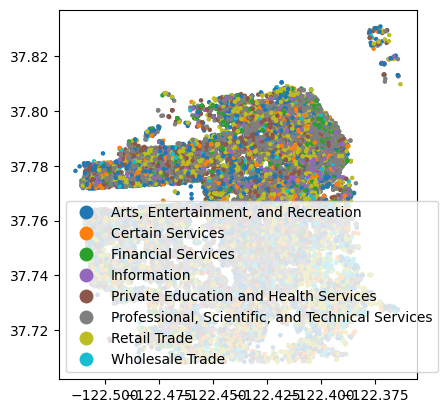

In [34]:
filtered_gdf.plot(
    column='naics_code_description',
    legend=True,
    markersize=5
)